<a href="https://colab.research.google.com/github/smritipioneer/Linear-regression-python-predictive-model-project-/blob/main/Predictive_modeling_Showtime_coded_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

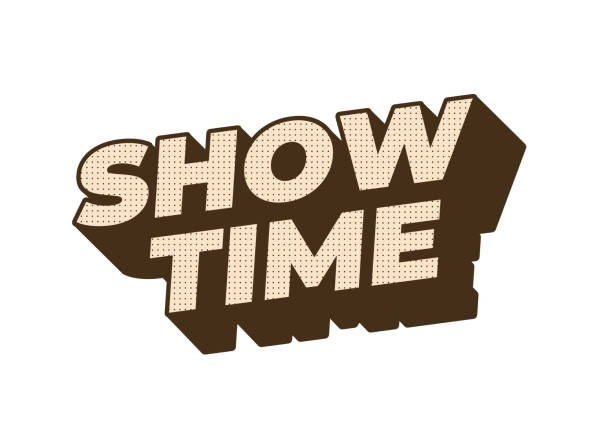

## Problem Statement

### Business Context

An over-the-top (OTT) media service is a media service offered directly to viewers via the internet. The term is most synonymous with subscription-based video-on-demand services that offer access to film and television content, including existing series acquired from other producers, as well as original content produced specifically for the service. They are typically accessed via websites on personal computers, apps on smartphones and tablets, or televisions with integrated Smart TV platforms.

Presently, OTT services are at a relatively nascent stage and are widely accepted as a trending technology across the globe. With the increasing change in customers' social behavior, which is shifting from traditional subscriptions to broadcasting services and OTT on-demand video and music subscriptions every year, OTT streaming is expected to grow at a very fast pace. The global OTT market size was valued at $121.61 billion in 2019 and is projected to reach $1,039.03 billion by 2027, growing at a CAGR of 29.4% from 2020 to 2027. The shift from television to OTT services for entertainment is driven by benefits such as on-demand services, ease of access, and access to better networks and digital connectivity.

With the outbreak of COVID19, OTT services are striving to meet the growing entertainment appetite of viewers, with some platforms already experiencing a 46% increase in consumption and subscriber count as viewers seek fresh content. With innovations and advanced transformations, which will enable the customers to access everything they want in a single space, OTT platforms across the world are expected to increasingly attract subscribers on a concurrent basis.



Objective

Objective
ShowTime is an OTT service provider and offers a wide variety of content (movies, web shows, etc.) for its users. They want to determine the driver variables for first-day content viewership so that they can take necessary measures to improve the viewership of the content on their platform. Some of the reasons for the decline in viewership of content would be the decline in the number of people coming to the platform, decreased marketing spend, content timing clashes, weekends and holidays, etc. They have hired you as a Data Scientist, shared the data of the current content in their platform, and asked you to analyze the data and come up with a linear regression model to determine the driving factors for first-day viewership.



Data Description
The data contains the different factors to analyze for the content. The detailed data dictionary is given below.

Data Dictionary:

visitors: Average number of visitors, in millions, to the platform in the past week

ad_impressions: Number of ad impressions, in millions, across all ad campaigns for the content (running and completed)

major_sports_event: Any major sports event on the day

genre: Genre of the content

dayofweek: Day of the release of the content

season: Season of the release of the content

views_trailer: Number of views, in millions, of the content trailer

views_content: Number of first-day views, in millions, of the content




Important Note
The following questions need to be answered as a part of the EDA section of the project:


What does the distribution of content views look like?

What does the distribution of genres look like?

The day of the week on which content is released generally plays a key role in the viewership. How does the viewership vary with the day of release?

How does the viewership vary with the season of release?

What is the correlation between trailer views and content views?




## Importing necessary libraries

In [ ]:
# Installing the libraries with the specified version.
!pip install scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.25.2 pandas==1.5.3 -q --user

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.8/294.8 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 33.5 MB/s eta 0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 1.5.3 which is incompatible.
cudf-cu12 25.2.1 requires pandas<2.2.4dev0,>=2.0, but you have pandas 1.5.3 which is incompatible.
dask-cudf-cu12 25.2.2 requires pandas<2.2.4dev0,>=2.0, but you have pandas 1.5.3 which is incompatible.
thinc 8.3.6 requires

In [ ]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

# split the data into train and test
from sklearn.model_selection import train_test_split

# to build linear regression_model
from sklearn.linear_model import LinearRegression

# to check model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# to build linear regression_model using statsmodels
import statsmodels.api as sm

# to compute VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Loading the dataset

In [ ]:
# loading data
data = pd.read_csv('/content/drive/MyDrive/ottdata.csv') ## Complete the code to read the data

## Data Overview

The initial steps to get an overview of any dataset is to:
- observe the first few rows of the dataset, to check whether the dataset has been loaded properly or not
- get information about the number of rows and columns in the dataset
- find out the data types of the columns to ensure that data is stored in the preferred format and the value of each property is as expected.
- checking the statistical summary of the dataset to get an overview of the numerical columns of the data

### Displaying the first few rows of the dataset

In [ ]:
data.head()

,visitors,ad_impressions,major_sports_event,genre,dayofweek,season,views_trailer,views_content
0,1.67,1113.81,0,Horror,Wednesday,Spring,56.70,0.51
1,1.46,1498.41,1,Thriller,Friday,Fall,52.69,0.32
2,1.47,1079.19,1,Thriller,Wednesday,Fall,48.74,0.39
3,1.85,1342.77,1,Sci-Fi,Friday,Fall,49.81,0.44
4,1.46,1498.41,0,Sci-Fi,Sunday,Winter,55.83,0.46


### Checking the shape of the dataset

In [ ]:
data.shape

(1000, 8)

### Checking the data types of the columns for the dataset

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   visitors            1000 non-null   float64
 1   ad_impressions      1000 non-null   float64
 2   major_sports_event  1000 non-null   int64  
 3   genre               1000 non-null   object 
 4   dayofweek           1000 non-null   object 
 5   season              1000 non-null   object 
 6   views_trailer       1000 non-null   float64
 7   views_content       1000 non-null   float64
dtypes: float64(4), int64(1), object(3)
memory usage: 62.6+ KB


### Statistical summary of the dataset

In [ ]:
data.describe().round(4)

,visitors,ad_impressions,major_sports_event,views_trailer,views_content
count,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000
mean,1.7043,1434.7123,0.4000,66.9156,0.4734
std,0.2320,289.5348,0.4901,35.0011,0.1059
min,1.2500,1010.8700,0.0000,30.0800,0.2200
25%,1.5500,1210.3300,0.0000,50.9475,0.4000
50%,1.7000,1383.5800,0.0000,53.9600,0.4500
75%,1.8300,1623.6700,1.0000,57.7550,0.5200
max,2.3400,2424.2000,1.0000,199.9200,0.8900


### Checking for duplicate values

In [ ]:
data.duplicated().sum()

np.int64(0)

### Checking for missing values

In [ ]:
data.isnull().sum()

,0
visitors,0
ad_impressions,0
major_sports_event,0
genre,0
dayofweek,0
season,0
views_trailer,0
views_content,0


In [ ]:
# creating a copy of the data so that original data remains unchanged
df = data.copy()

## Exploratory Data Analysis

### Univariate Analysis

In [ ]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

**`Visitors`**



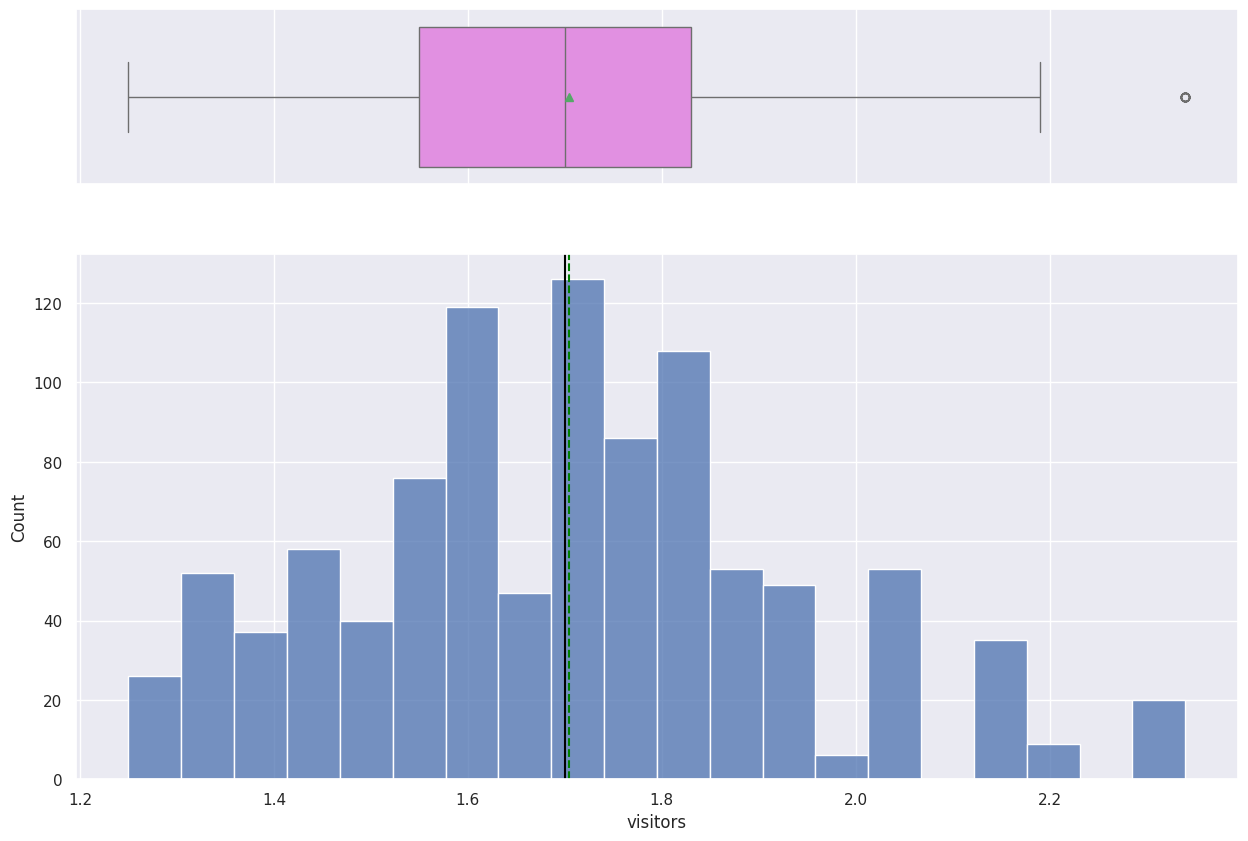

In [ ]:
histogram_boxplot(df, "visitors")

** Ad_impressions	`**

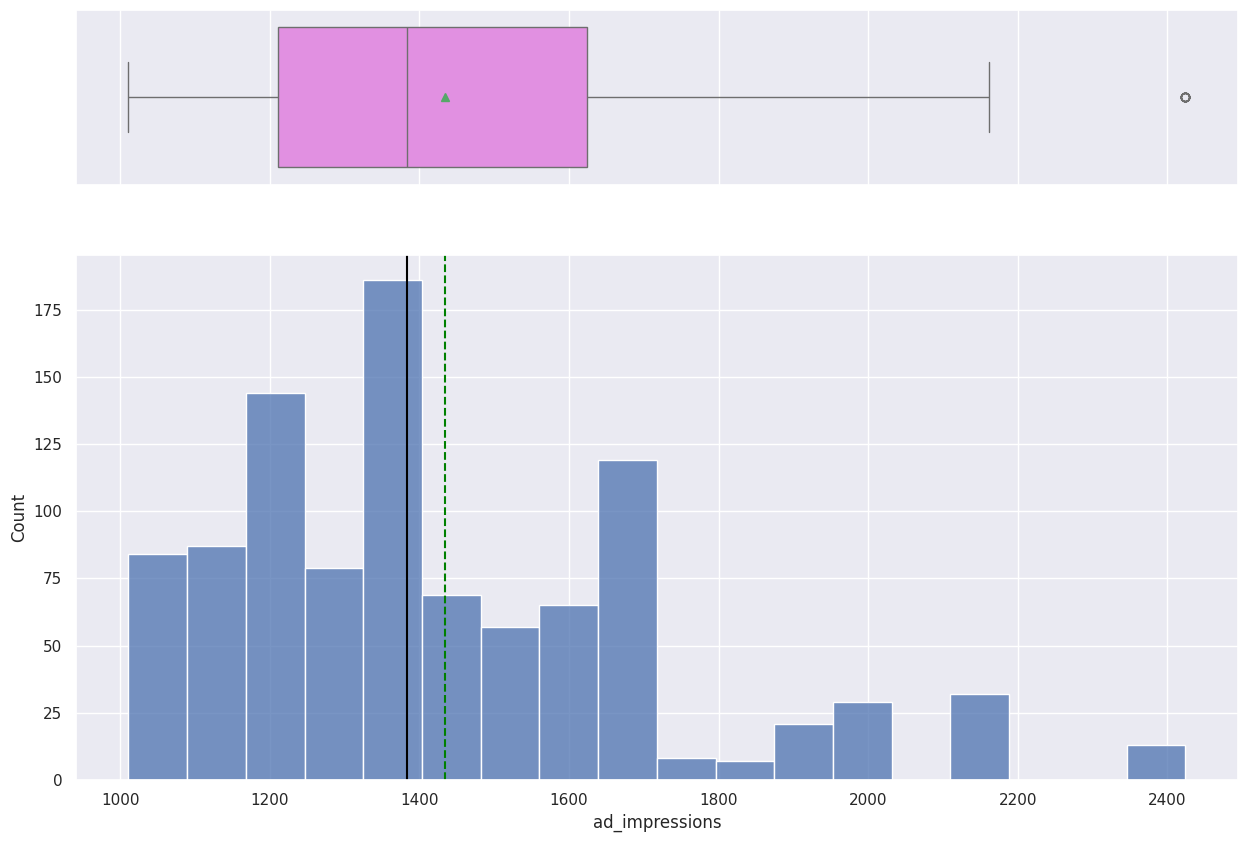

In [ ]:
histogram_boxplot(df, "ad_impressions")

**`Major_sports_event`**

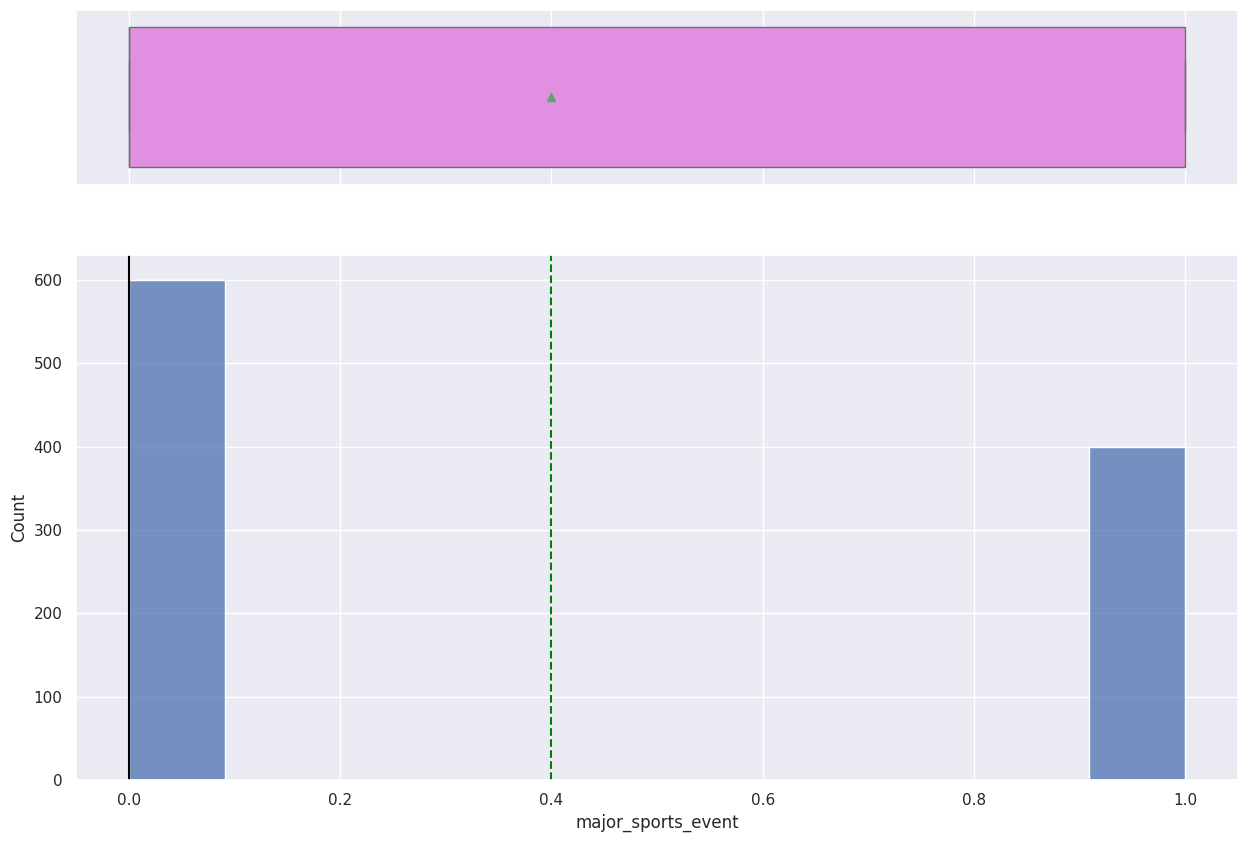

In [ ]:
histogram_boxplot(df, "major_sports_event")

**`Views_trailer	`**

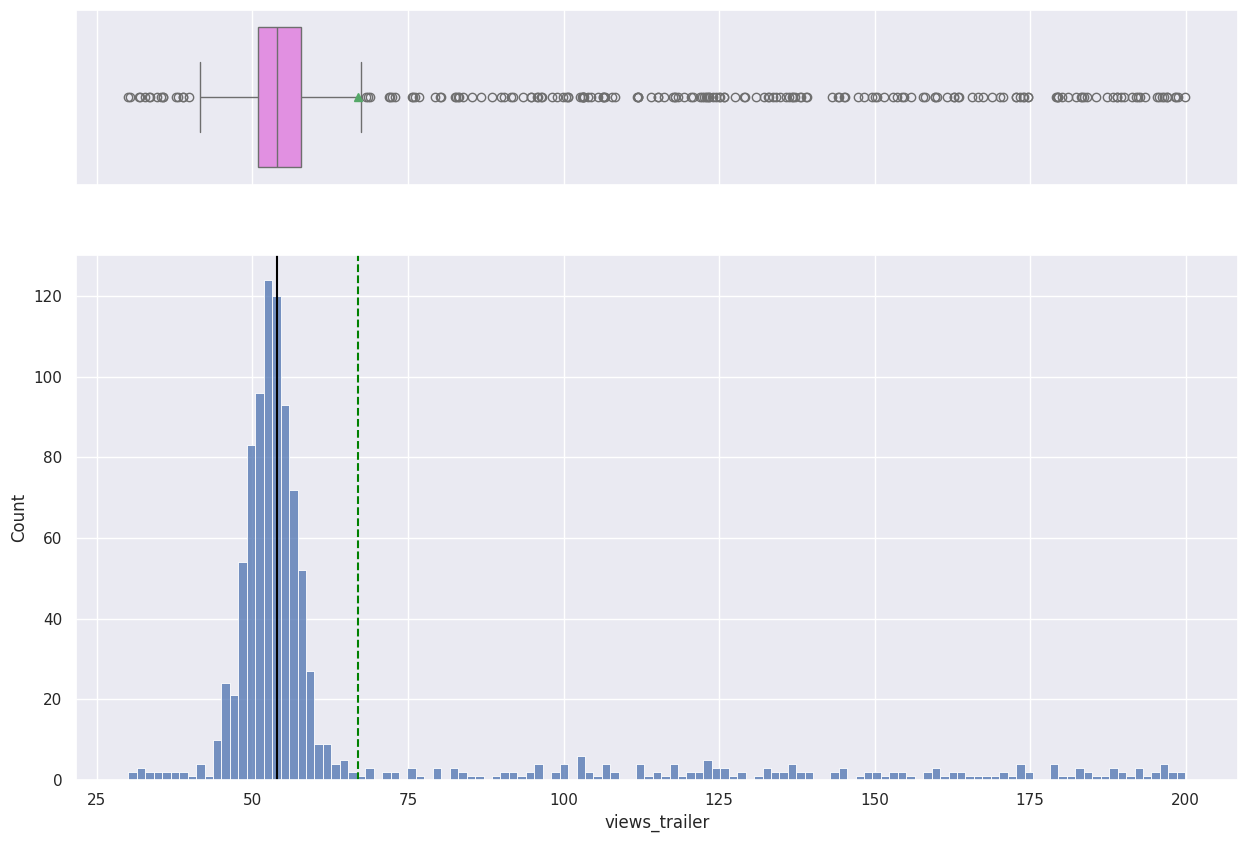

In [ ]:
histogram_boxplot(df, "views_trailer")

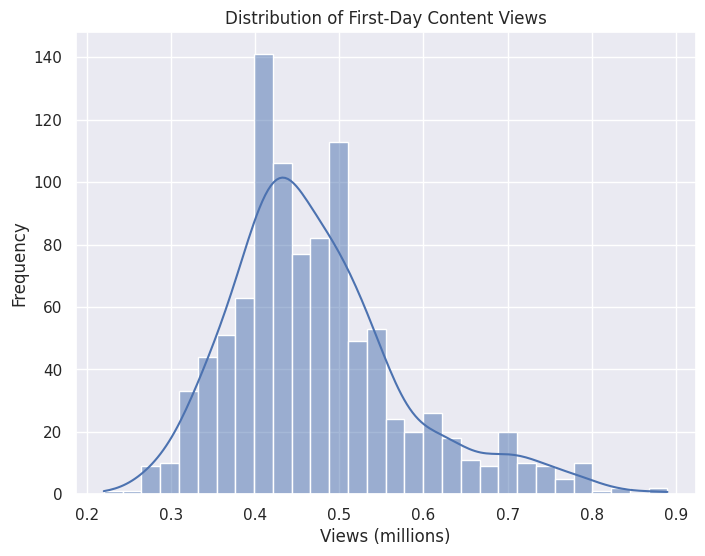

In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(df['views_content'], bins=30, kde=True)
plt.title('Distribution of First-Day Content Views')
plt.xlabel('Views (millions)')
plt.ylabel('Frequency')
plt.show()

**`views_content`**

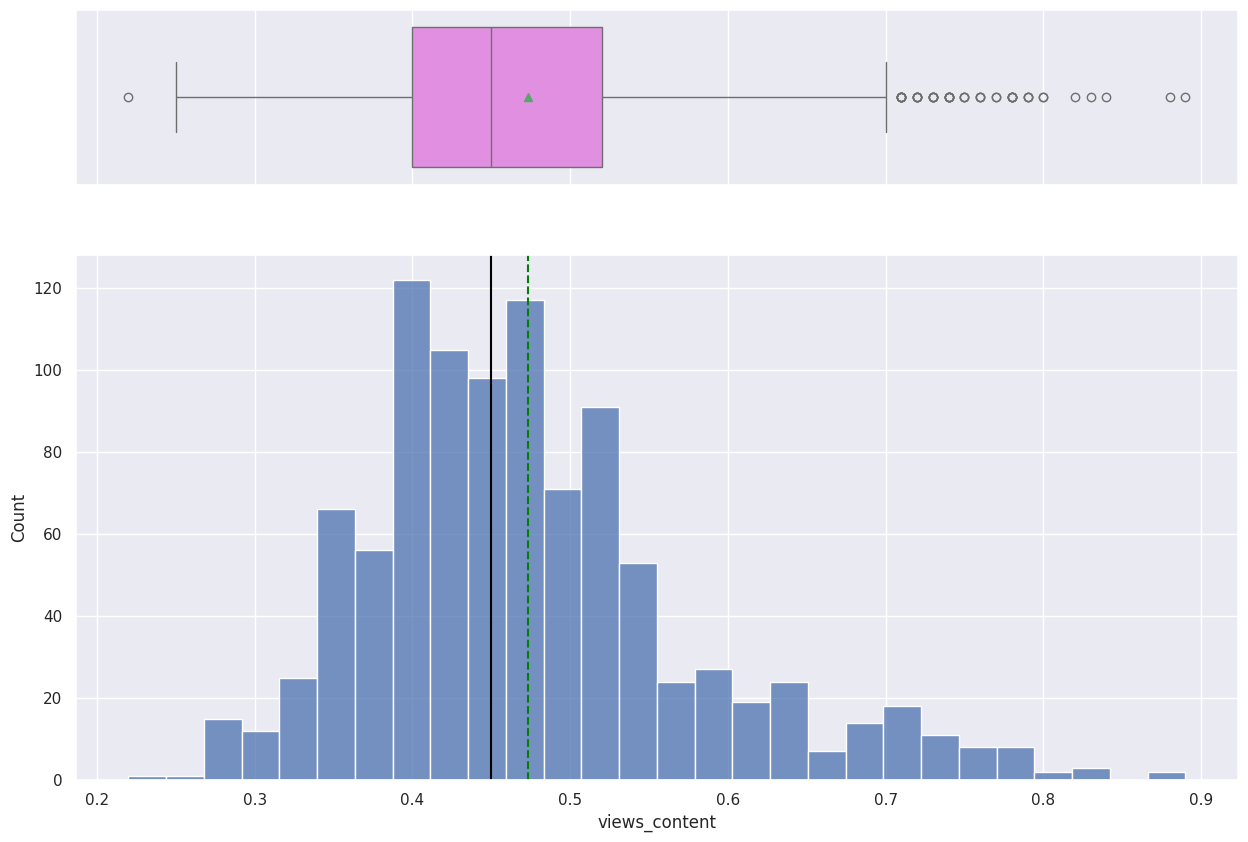

In [ ]:
histogram_boxplot(df, "views_content")

**`Genre`**

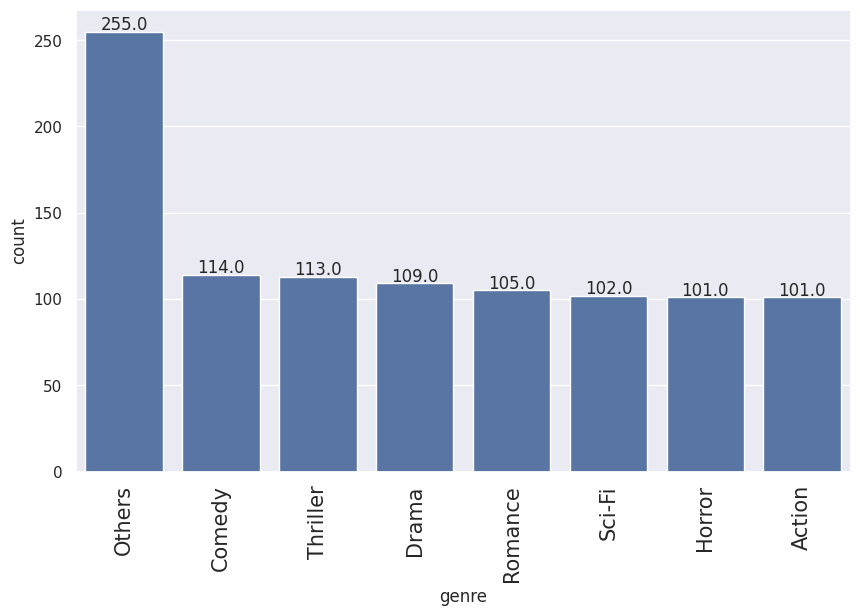

In [ ]:
labeled_barplot(df,'genre')

**`Day of week`**

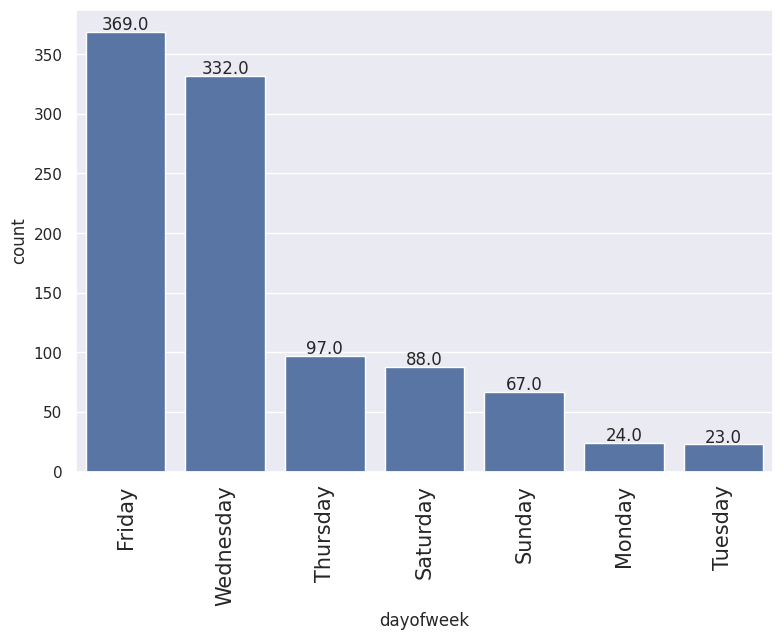

In [ ]:
labeled_barplot(df,'dayofweek')

**`Season`**

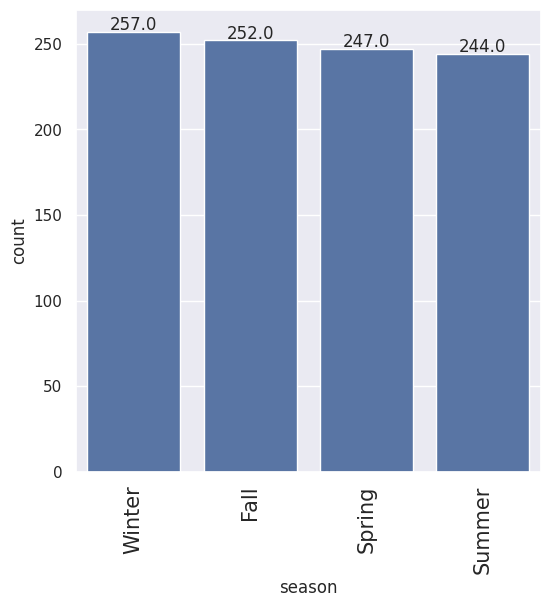

In [ ]:
labeled_barplot(df,'season')

In [ ]:
#we have many outliers in the data nut we are not deleting outliers as it is not wrong or type error in data i want to make predition taking in account of all data

### Bivariate Analysis

**Correlation Check**

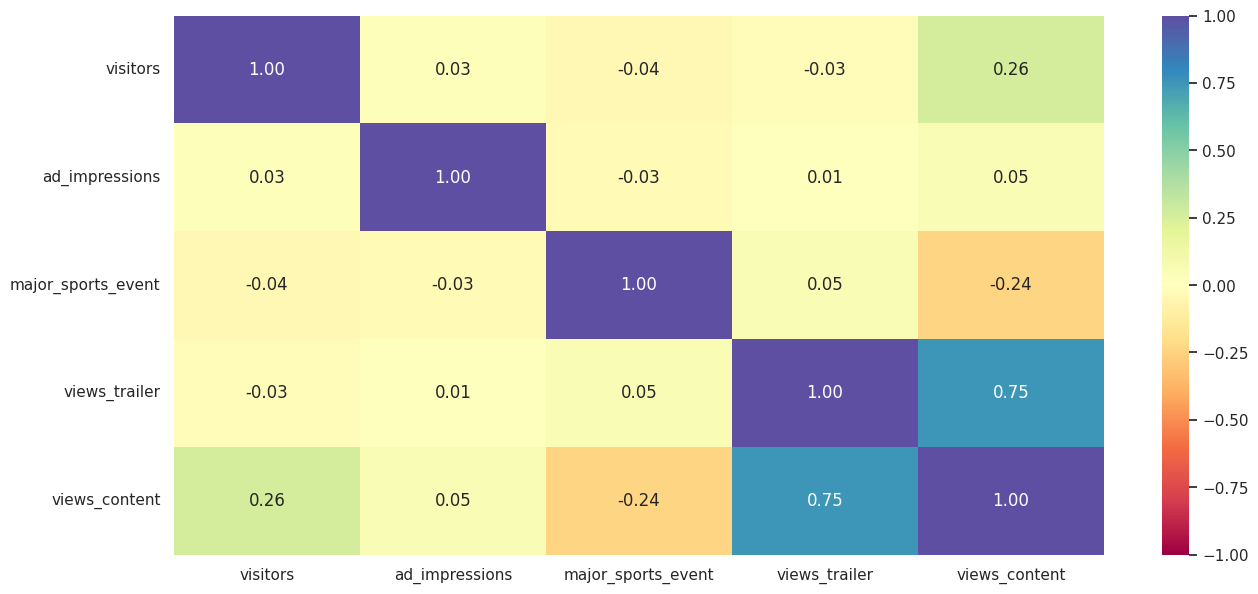

In [ ]:
cols_list = df.select_dtypes(include=np.number).columns.tolist()


plt.figure(figsize=(15, 7))
sns.heatmap(
    df[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

**Let's see how the views changes as per week days.**

In [ ]:
x=df.groupby(['season'])['views_content'].mean()
print(x)

season
Fall      0.445357
Spring    0.467166
Summer    0.496803
Winter    0.484669
Name: views_content, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

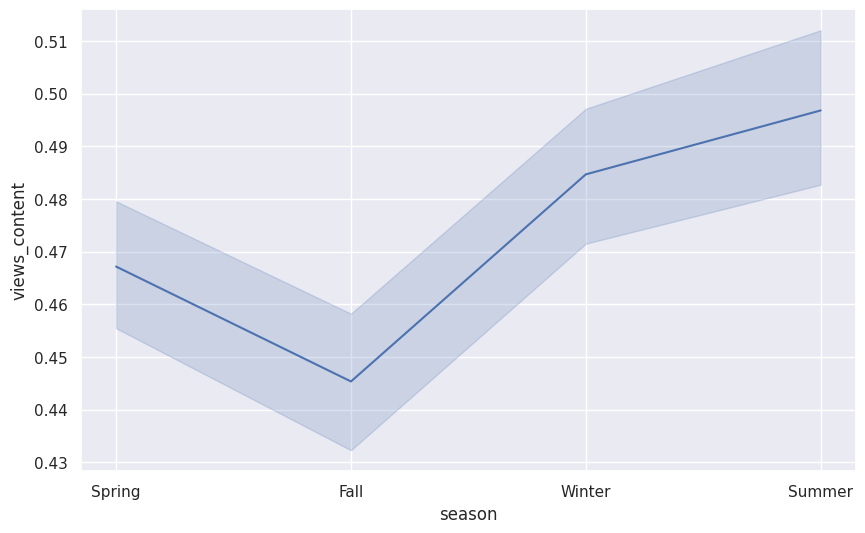

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='season', y='views_content', data=df)
plt.show

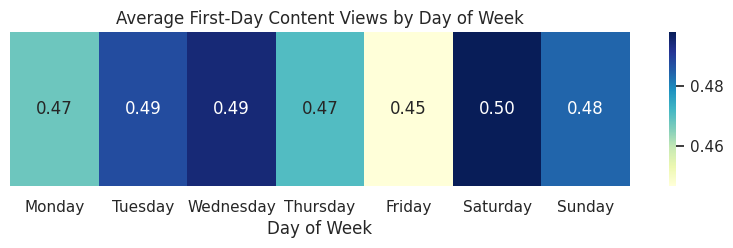

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# First, ensure 'dayofweek' is ordered properly
order_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Aggregate data: compute mean views for each day
mean_views_by_day = df.groupby('dayofweek')['views_content'].mean().reindex(order_days)

# Convert to DataFrame suitable for heatmap
heatmap_data = mean_views_by_day.to_frame().T  # Transpose for heatmap display

# Plot heatmap
plt.figure(figsize=(10,2))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap='YlGnBu')
plt.title('Average First-Day Content Views by Day of Week')
plt.xlabel('Day of Week')
plt.yticks([], [])  # Hide y-axis labels as only one row
plt.show()

In [ ]:
x=df.groupby(['dayofweek'])['views_content'].mean()

print(x)

dayofweek
Friday       0.446694
Monday       0.467917
Saturday     0.497955
Sunday       0.484179
Thursday     0.470619
Tuesday      0.487826
Wednesday    0.494608
Name: views_content, dtype: float64


**Let's check how the prices vary for used phones and tablets offering 4G and 5G networks.**

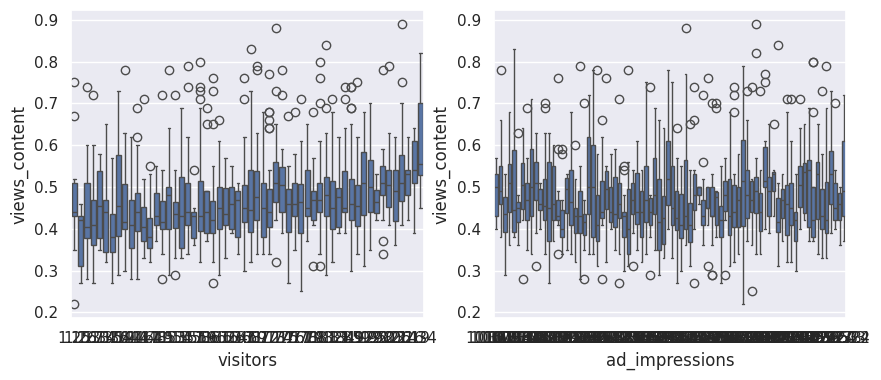

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(121)
sns.boxplot(data=df, x="visitors", y="views_content")

plt.subplot(122)
sns.boxplot(data=df, x="ad_impressions", y="views_content")

plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

<Figure size 2000x300 with 0 Axes>

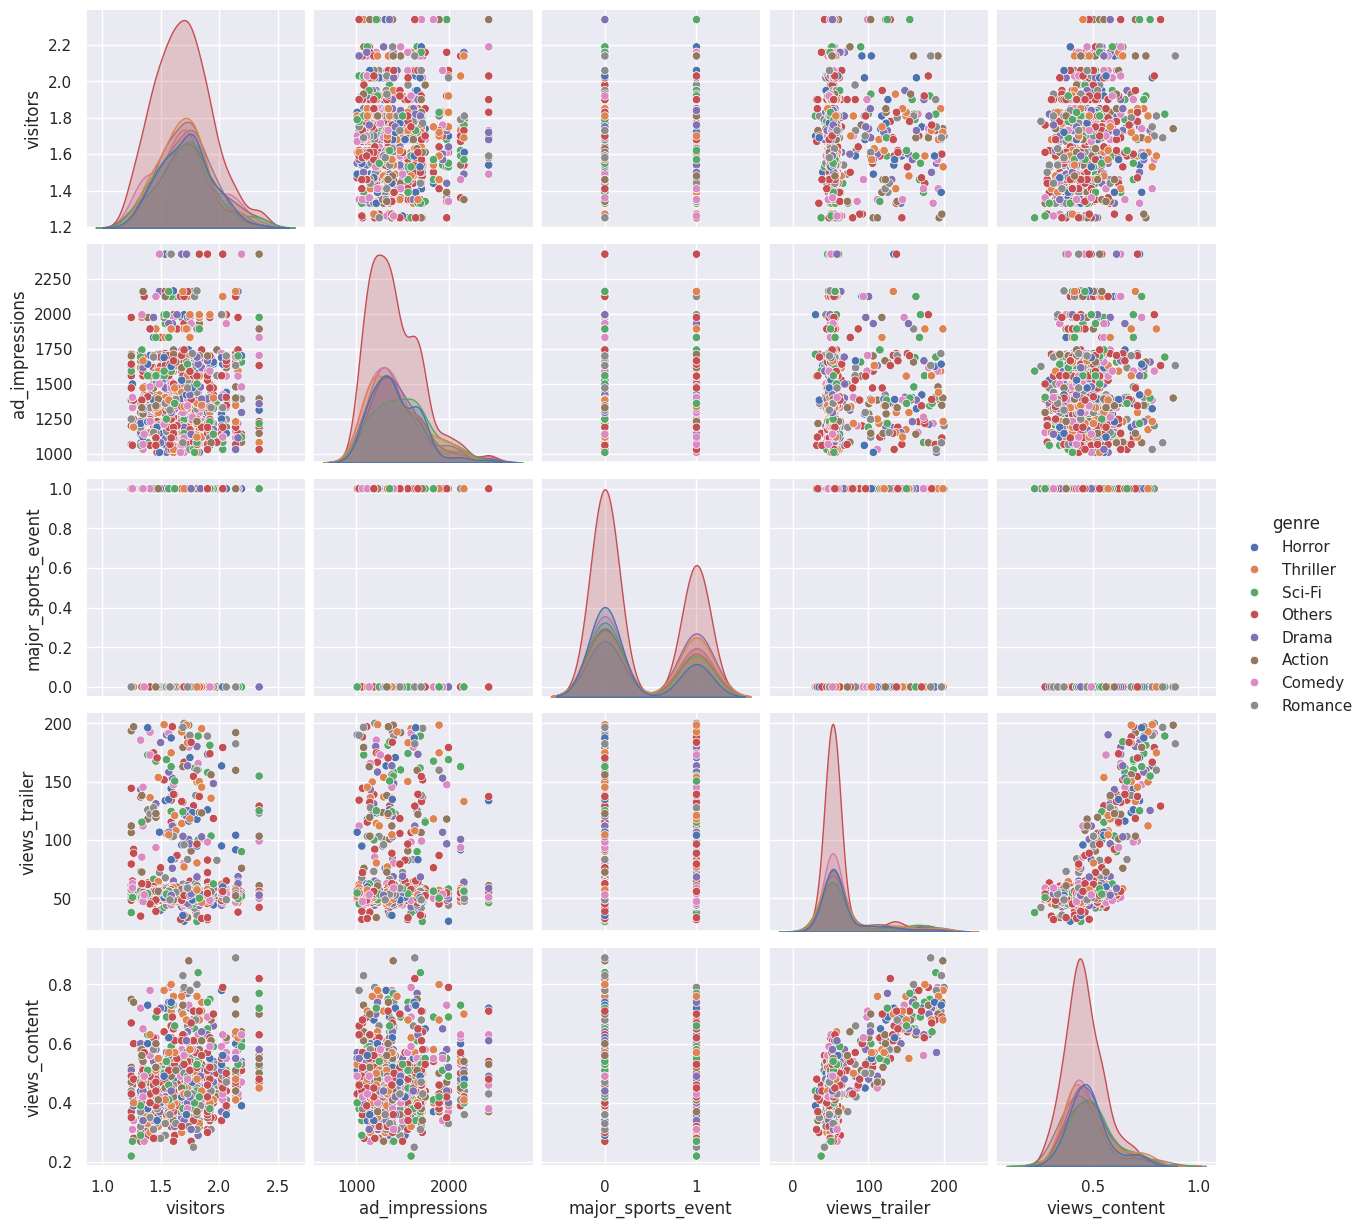

In [ ]:
plt.figure(figsize=(20, 3))
sns.pairplot(df, hue="genre")
plt.show

In [ ]:
table2= df.groupby(['genre'])['views_content'].mean()
print(table2)

genre
Action      0.487327
Comedy      0.474211
Drama       0.473945
Horror      0.481089
Others      0.459765
Romance     0.461238
Sci-Fi      0.493235
Thriller    0.476903
Name: views_content, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

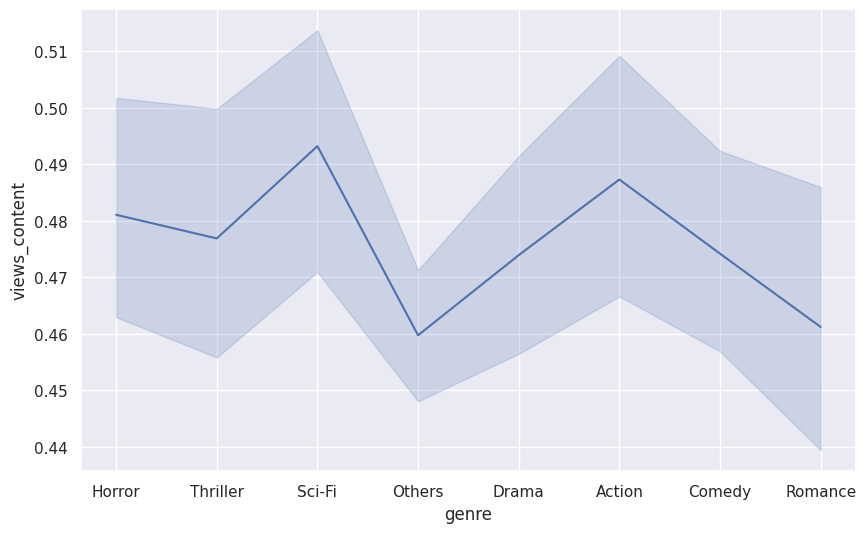

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='genre', y='views_content', data=df)
plt.show

## Data Preprocessing

### Outlier Check



- Let's check for outliers in the data.

In [ ]:
from copy import deepcopy
df1=deepcopy(df)

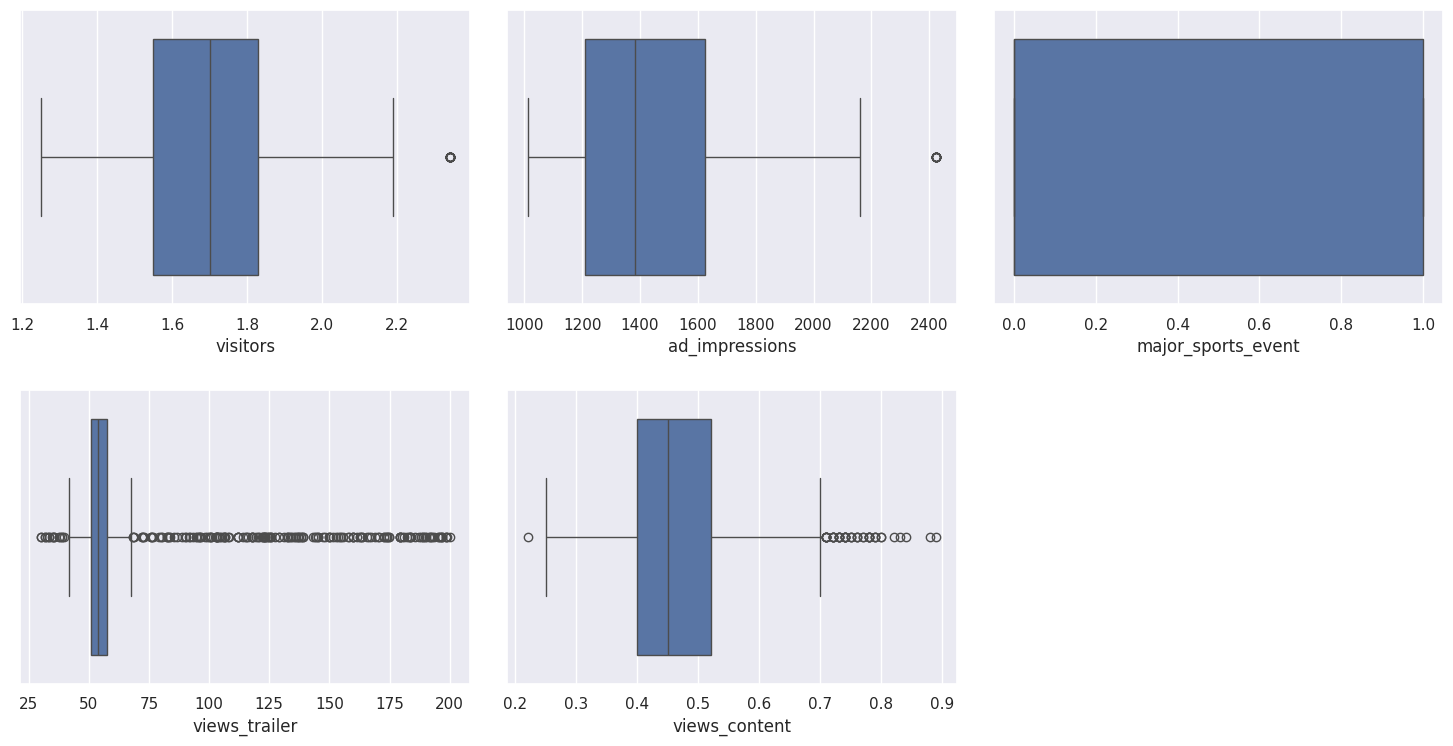

In [ ]:
# outlier detection using boxplot
num_cols = df1.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 15))

for i, variable in enumerate(num_cols):
    plt.subplot(4, 3, i + 1)
    sns.boxplot(data=df1, x=variable)
    plt.tight_layout(pad=2)

plt.show()

### Key questions

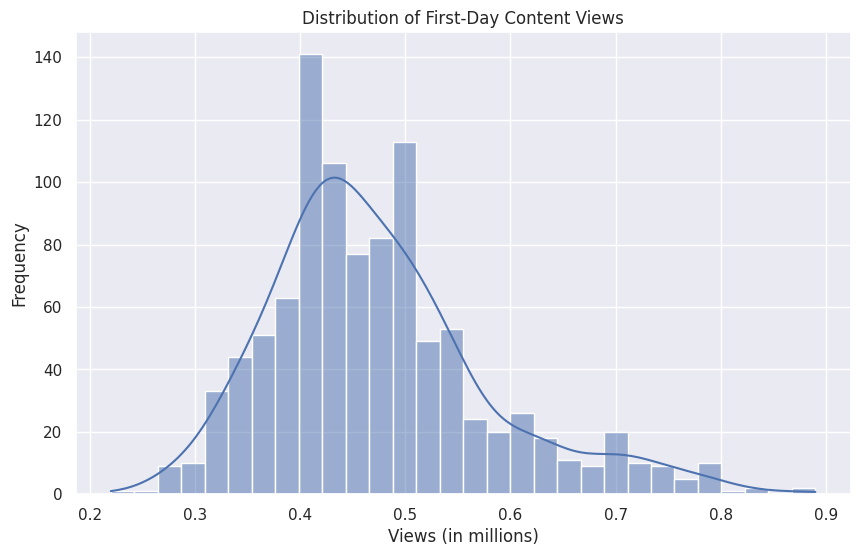

Mean of content views: 0.47 million
Median of content views: 0.45 million
Standard deviation: 0.11 million
The distribution appears right-skewed, indicating most content has lower views, with some high-view outliers.


In [ ]:
# 1. Distribution of Content Views (views_content)
plt.figure(figsize=(10,6))
sns.histplot(df['views_content'], bins=30, kde=True)
plt.title('Distribution of First-Day Content Views')
plt.xlabel('Views (in millions)')
plt.ylabel('Frequency')
plt.show()

# Summary
views_mean = df['views_content'].mean()
views_median = df['views_content'].median()
views_std = df['views_content'].std()

print(f"Mean of content views: {views_mean:.2f} million")
print(f"Median of content views: {views_median:.2f} million")
print(f"Standard deviation: {views_std:.2f} million")
print("The distribution appears right-skewed, indicating most content has lower views, with some high-view outliers.")

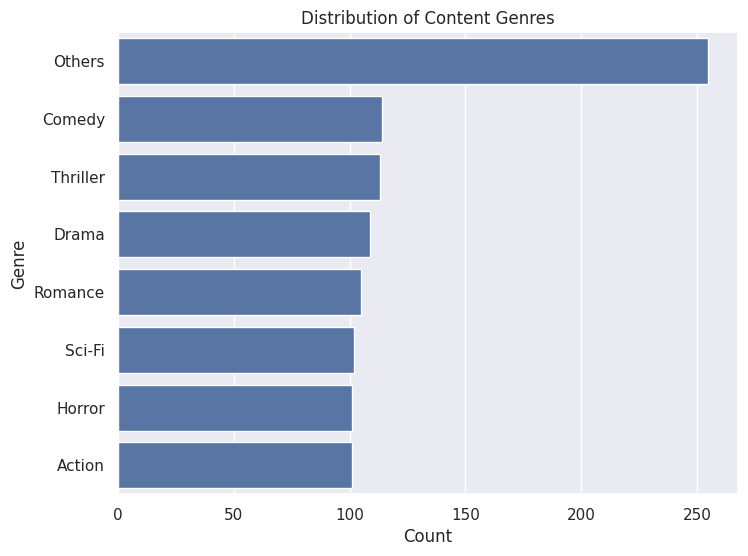

Genre distribution:
 genre
Others      255
Comedy      114
Thriller    113
Drama       109
Romance     105
Sci-Fi      102
Horror      101
Action      101
Name: count, dtype: int64


In [ ]:
# 2. Distribution of Genres
plt.figure(figsize=(8,6))
sns.countplot(y='genre', data=df, order=df['genre'].value_counts().index)
plt.title('Distribution of Content Genres')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

# Summary
genre_counts = df['genre'].value_counts()
print("Genre distribution:\n", genre_counts)

# Insights:
# Comedy and thriller are the most common genres which can influence marketing strategies.


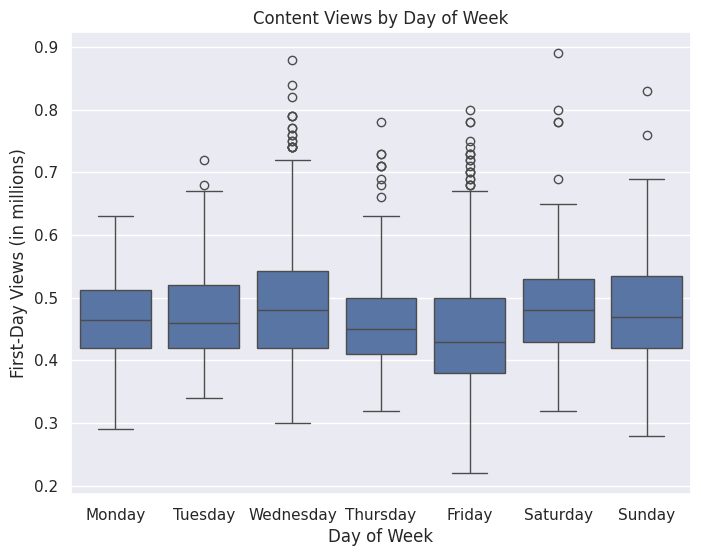

Average views by day of week:
 dayofweek
Monday       0.467917
Tuesday      0.487826
Wednesday    0.494608
Thursday     0.470619
Friday       0.446694
Saturday     0.497955
Sunday       0.484179
Name: views_content, dtype: float64


In [ ]:
# 3. Viewership Variation by Day of the Week
plt.figure(figsize=(8,6))
sns.boxplot(x='dayofweek', y='views_content', data=df, order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('Content Views by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('First-Day Views (in millions)')
plt.show()

# Summary
day_views = df.groupby('dayofweek')['views_content'].mean().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
print("Average views by day of week:\n", day_views)

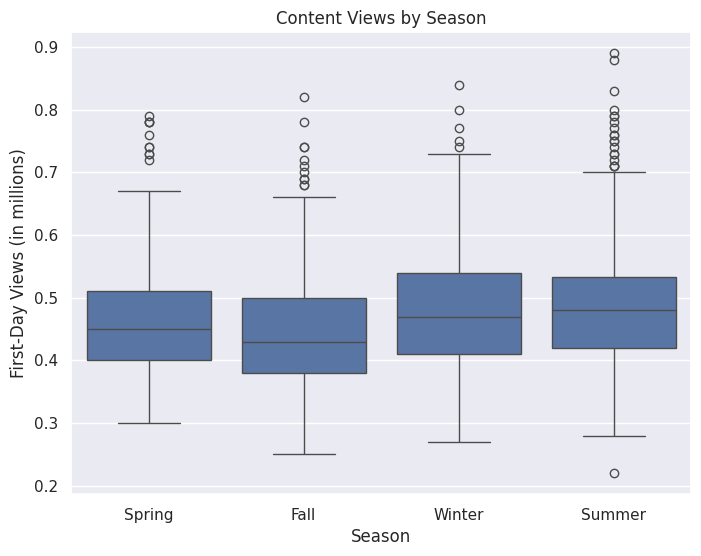

Average views by season:
 season
Fall      0.445357
Spring    0.467166
Summer    0.496803
Winter    0.484669
Name: views_content, dtype: float64


In [ ]:
# 4. Viewership Variation by Season
plt.figure(figsize=(8,6))
sns.boxplot(x='season', y='views_content', data=df, order=df['season'].unique())
plt.title('Content Views by Season')
plt.xlabel('Season')
plt.ylabel('First-Day Views (in millions)')
plt.show()

# Summary
season_views = df.groupby('season')['views_content'].mean()
print("Average views by season:\n", season_views)

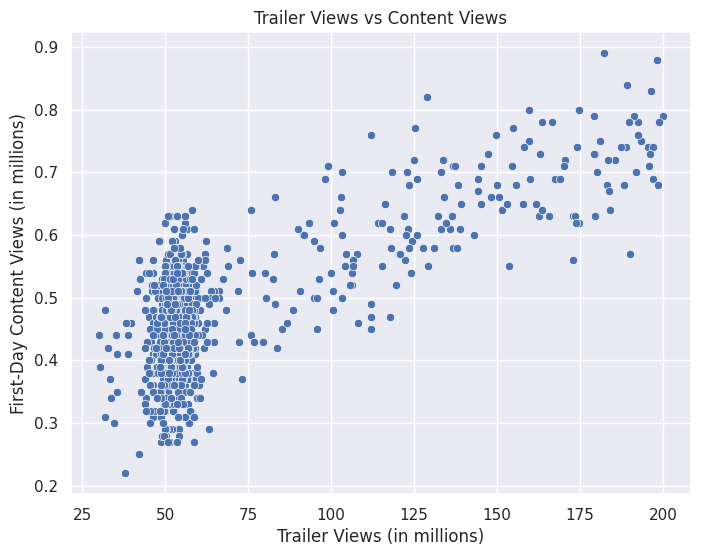

Correlation between trailer views and content views: 0.75


In [ ]:
# 5. Correlation between Trailer Views and Content Views
plt.figure(figsize=(8,6))
sns.scatterplot(x='views_trailer', y='views_content', data=df)
plt.title('Trailer Views vs Content Views')
plt.xlabel('Trailer Views (in millions)')
plt.ylabel('First-Day Content Views (in millions)')
plt.show()

# Calculate correlation coefficient
corr_trailer_views = df['views_trailer'].corr(df['views_content'])
print(f"Correlation between trailer views and content views: {corr_trailer_views:.2f}")


Missing values in each column:
 visitors              0
ad_impressions        0
major_sports_event    0
genre                 0
dayofweek             0
season                0
views_trailer         0
views_content         0
dtype: int64


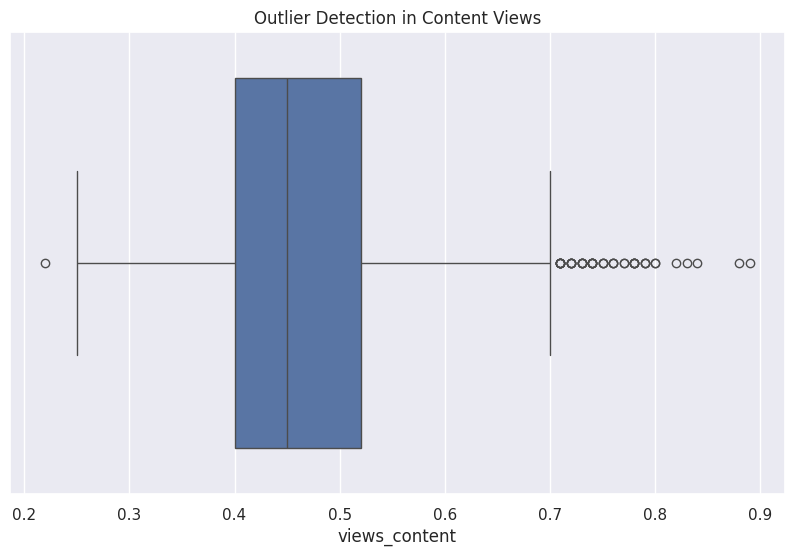

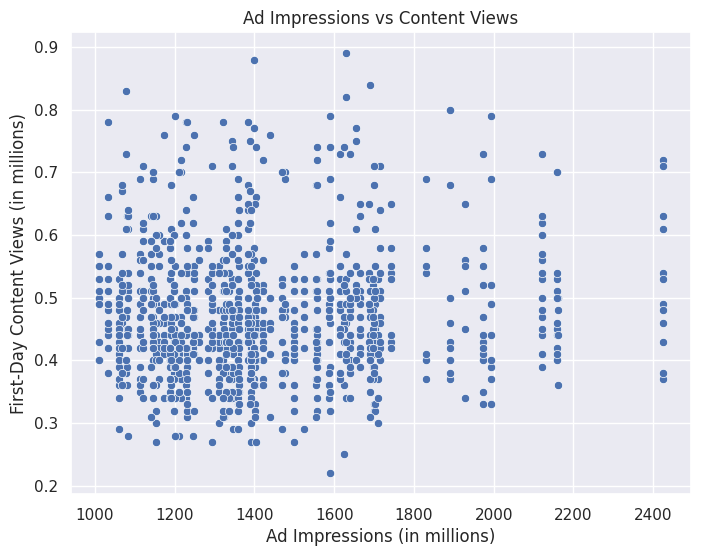

Correlation between ad impressions and content views: 0.05


In [ ]:
# 6. Additional EDA insights (beyond the specific questions)
# Check for missing values
print("Missing values in each column:\n", df.isnull().sum())

# Check for outliers in 'views_content'
plt.figure(figsize=(10,6))
sns.boxplot(x=df['views_content'])
plt.title('Outlier Detection in Content Views')
plt.show()

# Summary:
# - Address missing data if any.
# - Outliers may need to be treated or considered during modeling.

# 7. Relationship with other variables
# For example, ad impressions
plt.figure(figsize=(8,6))
sns.scatterplot(x='ad_impressions', y='views_content', data=df)
plt.title('Ad Impressions vs Content Views')
plt.xlabel('Ad Impressions (in millions)')
plt.ylabel('First-Day Content Views (in millions)')
plt.show()

# Correlation
ad_views_corr = df['ad_impressions'].corr(df['views_content'])
print(f"Correlation between ad impressions and content views: {ad_views_corr:.2f}")





```
# This is formatted as code
```

### Data Preparation for modeling

- we'll have to encode categorical features
- We'll split the data into train and test to be able to evaluate the model that we build on the train data
- We will build a Linear Regression model using the train data and then check it's performance

In [ ]:
## Define the dependent and independent variable

X = df1.drop(["views_content"], axis=1)
y = df1["views_content"]

print(X.head())
print()
print(y.head())

   visitors  ad_impressions  major_sports_event     genre  dayofweek  season  \
0      1.67         1113.81                   0    Horror  Wednesday  Spring   
1      1.46         1498.41                   1  Thriller     Friday    Fall   
2      1.47         1079.19                   1  Thriller  Wednesday    Fall   
3      1.85         1342.77                   1    Sci-Fi     Friday    Fall   
4      1.46         1498.41                   0    Sci-Fi     Sunday  Winter   

   views_trailer  
0          56.70  
1          52.69  
2          48.74  
3          49.81  
4          55.83  

0    0.51
1    0.32
2    0.39
3    0.44
4    0.46
Name: views_content, dtype: float64


In [ ]:
# let's add the intercept to data
X = sm.add_constant(X)

In [ ]:
# creating dummy variables
X = pd.get_dummies(
    X,
    columns=X.select_dtypes(include=["object", "category"]).columns.tolist(),
    drop_first=True,
)

X.head()

,const,visitors,ad_impressions,major_sports_event,views_trailer,genre_Comedy,genre_Drama,genre_Horror,genre_Others,genre_Romance,...,genre_Thriller,dayofweek_Monday,dayofweek_Saturday,dayofweek_Sunday,dayofweek_Thursday,dayofweek_Tuesday,dayofweek_Wednesday,season_Spring,season_Summer,season_Winter
0,1.0,1.67,1113.81,0,56.70,False,False,True,False,False,...,False,False,False,False,False,False,True,True,False,False
1,1.0,1.46,1498.41,1,52.69,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2,1.0,1.47,1079.19,1,48.74,False,False,False,False,False,...,True,False,False,False,False,False,True,False,False,False
3,1.0,1.85,1342.77,1,49.81,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1.0,1.46,1498.41,0,55.83,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True


In [ ]:
# converting the input attributes into float type for modeling
X = X.astype(float)
X.head()

,const,visitors,ad_impressions,major_sports_event,views_trailer,genre_Comedy,genre_Drama,genre_Horror,genre_Others,genre_Romance,...,genre_Thriller,dayofweek_Monday,dayofweek_Saturday,dayofweek_Sunday,dayofweek_Thursday,dayofweek_Tuesday,dayofweek_Wednesday,season_Spring,season_Summer,season_Winter
0,1.0,1.67,1113.81,0.0,56.70,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,1.0,1.46,1498.41,1.0,52.69,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,1.47,1079.19,1.0,48.74,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,1.0,1.85,1342.77,1.0,49.81,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,1.46,1498.41,0.0,55.83,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
X.shape

(1000, 21)

In [ ]:
X.isnull().sum()

,0
const,0
visitors,0
ad_impressions,0
major_sports_event,0
views_trailer,0
genre_Comedy,0
genre_Drama,0
genre_Horror,0
genre_Others,0
genre_Romance,0


In [ ]:
# splitting the data in 70:30 ratio for train to test data

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state = 74)

In [ ]:
print("Number of rows in train data =", x_train.shape[0])
print("Number of rows in test data =", x_test.shape[0])

Number of rows in train data = 700
Number of rows in test data = 300


## Model Building - Linear Regression


In [ ]:
np.asarray(data)

array([[1.67, 1113.81, 0, ..., 'Spring', 56.7, 0.51],
       [1.46, 1498.41, 1, ..., 'Fall', 52.69, 0.32],
       [1.47, 1079.19, 1, ..., 'Fall', 48.74, 0.39],
       ...,
       [1.62, 1359.8, 1, ..., 'Fall', 150.44, 0.66],
       [2.06, 1698.35, 0, ..., 'Summer', 48.72, 0.47],
       [1.36, 1140.23, 0, ..., 'Summer', 52.94, 0.49]], dtype=object)

In [ ]:
olsmodel = sm.OLS(y_train, x_train).fit()
print(olsmodel.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.791
Model:                            OLS   Adj. R-squared:                  0.785
Method:                 Least Squares   F-statistic:                     128.8
Date:                Wed, 09 Jul 2025   Prob (F-statistic):          1.91e-215
Time:                        05:49:51   Log-Likelihood:                 1113.0
No. Observations:                 700   AIC:                            -2184.
Df Residuals:                     679   BIC:                            -2088.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0411    

In [ ]:
olsmodel = sm.OLS(y_test, x_test).fit()
print(olsmodel.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.788
Model:                            OLS   Adj. R-squared:                  0.772
Method:                 Least Squares   F-statistic:                     51.73
Date:                Wed, 09 Jul 2025   Prob (F-statistic):           1.22e-81
Time:                        05:49:51   Log-Likelihood:                 495.70
No. Observations:                 300   AIC:                            -949.4
Df Residuals:                     279   BIC:                            -871.6
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0973    

### Model Performance Check

**Let's check the performance of the model using different metrics.**

* We will be using metric functions defined in sklearn for RMSE, MAE, and $R^2$.
* We will define a function to calculate MAPE and adjusted $R^2$.    
* We will create a function which will print out all the above metrics in one go.

In [ ]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute MAPE
def mape_score(targets, predictions):
    return np.mean(np.abs(targets - predictions) / targets) * 100


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mape_score(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

In [ ]:
# checking model performance on train set (seen 70% data)
print("Training Performance\n")
olsmodel_train_perf = model_performance_regression(olsmodel, x_train, y_train)
olsmodel_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.051711,0.040749,0.77088,0.763783,9.148103


In [ ]:
# checking model performance on test set (seen 30% data)
print("Test Performance\n")
olsmodel_test_perf = model_performance_regression(olsmodel, x_test, y_test)
olsmodel_test_perf

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.046362,0.037534,0.787621,0.771578,8.332598


In [ ]:
# Step 6: Display model coefficients with feature names
coefficients = pd.Series(olsmodel.params, index=X.columns)
print("\nModel Coefficients:")
print(coefficients.sort_values(ascending=False))


Model Coefficients:
visitors               1.070098e-01
const                  9.730536e-02
dayofweek_Saturday     5.150950e-02
season_Summer          5.007288e-02
dayofweek_Wednesday    5.006811e-02
dayofweek_Monday       3.623749e-02
season_Winter          3.110703e-02
dayofweek_Sunday       2.854567e-02
genre_Sci-Fi           2.781462e-02
genre_Thriller         2.512281e-02
season_Spring          2.497351e-02
dayofweek_Thursday     1.720763e-02
genre_Drama            1.661638e-02
genre_Horror           1.573393e-02
genre_Comedy           1.469187e-02
genre_Others           1.169740e-02
genre_Romance          4.973963e-03
views_trailer          2.332912e-03
ad_impressions        -2.032572e-07
dayofweek_Tuesday     -2.451453e-02
major_sports_event    -6.324752e-02
dtype: float64


## Checking Linear Regression Assumptions

We will be checking the following Linear Regression assumptions:

1. **No Multicollinearity**

2. **Linearity of variables**

3. **Independence of error terms**

4. **Normality of error terms**

5. **No Heteroscedasticity**

### TEST FOR MULTICOLLINEARITY



- We will test for multicollinearity using VIF.

- **General Rule of thumb**:
    - If VIF is 1 then there is no correlation between the $k$th predictor and the remaining predictor variables.
    - If VIF exceeds 5 or is close to exceeding 5, we say there is moderate multicollinearity.
    - If VIF is 10 or exceeding 10, it shows signs of high multicollinearity.

Let's define a function to check VIF.

In [ ]:
#Let's define a function to check VIF.

def checking_vif(predictors):
    vif = pd.DataFrame()
    vif["feature"] = predictors.columns

    # calculating VIF for each feature
    vif["VIF"] = [
        variance_inflation_factor(predictors.values, i)
        for i in range(len(predictors.columns))
    ]
    return vif

In [ ]:
checking_vif(x_train)

,feature,VIF
0,const,97.922272
1,visitors,1.022576
2,ad_impressions,1.027766
3,major_sports_event,1.056705
4,views_trailer,1.014196
5,genre_Comedy,1.973516
6,genre_Drama,1.919608
7,genre_Horror,1.792227
8,genre_Others,2.732459
9,genre_Romance,1.963559


As we can see no feature is having higher VIF then we can continue to next check for multicoliearity

### Removing Multicollinearity (if needed)



To remove multicollinearity

1. Drop every column one by one that has a VIF score greater than 5.
2. Look at the adjusted R-squared and RMSE of all these models.
3. Drop the variable that makes the least change in adjusted R-squared.
4. Check the VIF scores again.
5. Continue till you get all VIF scores under 5.

Let's define a function that will help us do this.

### Dropping high p-value variables (if needed)

- We will drop the predictor variables having a p-value greater than 0.05 as they do not significantly impact the target variable.
- But sometimes p-values change after dropping a variable. So, we'll not drop all variables at once.
- Instead, we will do the following:
    - Build a model, check the p-values of the variables, and drop the column with the highest p-value.
    - Create a new model without the dropped feature, check the p-values of the variables, and drop the column with the highest p-value.
    - Repeat the above two steps till there are no columns with p-value > 0.05.

The above process can also be done manually by picking one variable at a time that has a high p-value, dropping it, and building a model again. But that might be a little tedious and using a loop will be more efficient.

In [ ]:
# initial list of columns
predictors = x_train
cols = predictors.columns.tolist()

# setting an initial max p-value
max_p_value = 1

while len(cols) > 0:
    # defining the train set
    x_train_aux = predictors[cols]

    # fitting the model
    model = sm.OLS(y_train, x_train_aux).fit()

    # getting the p-values and the maximum p-value
    p_values = model.pvalues
    max_p_value = max(p_values)

    # name of the variable with maximum p-value
    feature_with_p_max = p_values.idxmax()

    if max_p_value > 0.05:
        cols.remove(feature_with_p_max)
    else:
        break

selected_features = cols
print(selected_features)

['const', 'visitors', 'major_sports_event', 'views_trailer', 'dayofweek_Saturday', 'dayofweek_Sunday', 'dayofweek_Thursday', 'dayofweek_Tuesday', 'dayofweek_Wednesday', 'season_Spring', 'season_Summer', 'season_Winter']


In [ ]:
X_train3 = x_train[selected_features]
X_test3 = x_test[selected_features]

In [ ]:
olsmodel2 = sm.OLS(y_train, X_train3).fit()
print(olsmodel2.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.788
Model:                            OLS   Adj. R-squared:                  0.785
Method:                 Least Squares   F-statistic:                     232.4
Date:                Wed, 09 Jul 2025   Prob (F-statistic):          3.69e-223
Time:                        05:49:51   Log-Likelihood:                 1107.2
No. Observations:                 700   AIC:                            -2190.
Df Residuals:                     688   BIC:                            -2136.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0643    

In [ ]:
# checking model performance on train set (seen 70% data)
print("Training Performance\n")
olsmodel2_train_perf = model_performance_regression(olsmodel2, X_train3, y_train)
olsmodel2_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.049751,0.039016,0.787914,0.78421,8.692634


In [ ]:
# checking model performance on test set (seen 30% data)
print("Test Performance\n")
olsmodel2_test_perf = model_performance_regression(olsmodel2, X_test3, y_test)
olsmodel2_test_perf

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.049756,0.040026,0.755396,0.745169,8.820751


In [ ]:
coefficients2 = pd.Series(olsmodel2.params, index=X_train3.columns)
print("\nModel Coefficients:")
print(coefficients.sort_values(ascending=False))


Model Coefficients:
visitors               1.070098e-01
const                  9.730536e-02
dayofweek_Saturday     5.150950e-02
season_Summer          5.007288e-02
dayofweek_Wednesday    5.006811e-02
dayofweek_Monday       3.623749e-02
season_Winter          3.110703e-02
dayofweek_Sunday       2.854567e-02
genre_Sci-Fi           2.781462e-02
genre_Thriller         2.512281e-02
season_Spring          2.497351e-02
dayofweek_Thursday     1.720763e-02
genre_Drama            1.661638e-02
genre_Horror           1.573393e-02
genre_Comedy           1.469187e-02
genre_Others           1.169740e-02
genre_Romance          4.973963e-03
views_trailer          2.332912e-03
ad_impressions        -2.032572e-07
dayofweek_Tuesday     -2.451453e-02
major_sports_event    -6.324752e-02
dtype: float64


**Now we'll check the rest of the assumptions on *olsmod2*.**

2. **Linearity of variables**

3. **Independence of error terms**

4. **Normality of error terms**

5. **No Heteroscedasticity**

### TEST FOR LINEARITY AND INDEPENDENCE



- We will test for linearity and independence by making a plot of fitted values vs residuals and checking for patterns.
- If there is no pattern, then we say the model is linear and residuals are independent.
- Otherwise, the model is showing signs of non-linearity and residuals are not independent.

In [ ]:
# let us create a dataframe with actual, fitted and residual values
df_pred = pd.DataFrame()

df_pred["Actual Values"] = y_train  # actual values
df_pred["Fitted Values"] = olsmodel2.fittedvalues  # predicted values
df_pred["Residuals"] = olsmodel2.resid  # residuals

df_pred.head()

,Actual Values,Fitted Values,Residuals
240,0.51,0.536482,-0.026482
651,0.79,0.768104,0.021896
8,0.36,0.378157,-0.018157
202,0.48,0.437140,0.042860
364,0.51,0.485007,0.024993


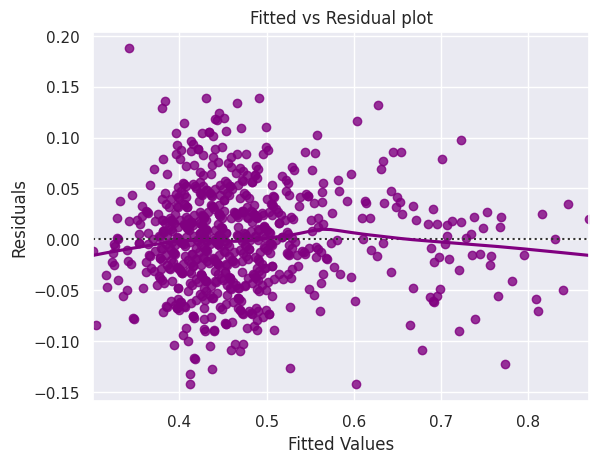

In [ ]:
# let's plot the fitted values vs residuals

sns.residplot(
    data=df_pred, x="Fitted Values", y="Residuals", color="purple", lowess=True
)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Fitted vs Residual plot")
plt.show()

**Conclusion** - As there is no pattern in plot,hence we say the model is linear and residuals are independent.

### TEST FOR NORMALITY

- We will test for normality by checking the distribution of residuals, by checking the Q-Q plot of residuals, and by using the Shapiro-Wilk test.
- If the residuals follow a normal distribution, they will make a straight line plot, otherwise not.
- If the p-value of the Shapiro-Wilk test is greater than 0.05, we can say the residuals are normally distributed.

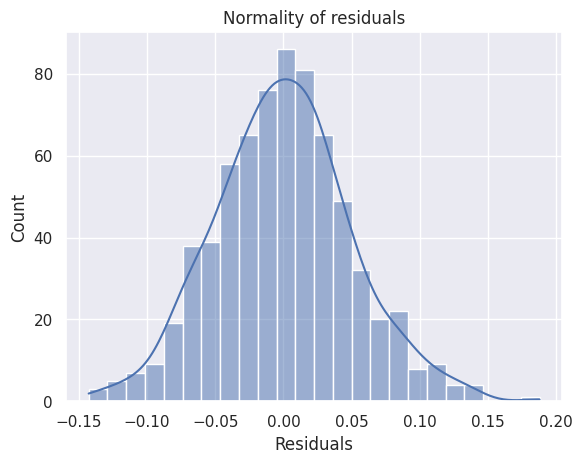

In [ ]:
sns.histplot(data=df_pred, x="Residuals", kde=True)
plt.title("Normality of residuals")
plt.show()

##the code check Q-Q plot##

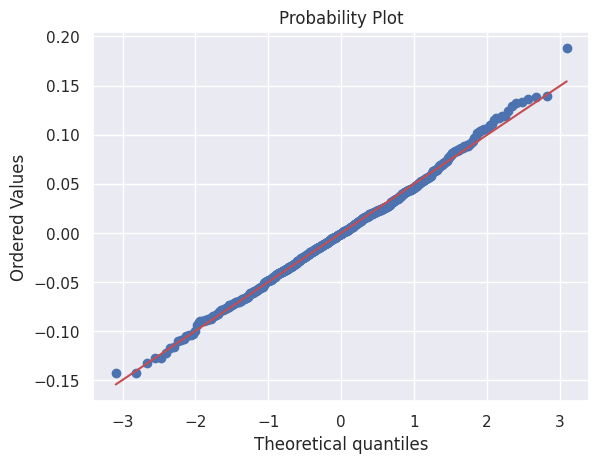

In [ ]:
import pylab
import scipy.stats as stats

stats.probplot(df_pred["Residuals"], dist="norm", plot=pylab)
plt.show()

In [ ]:
## The code to apply the Shapiro-Wilks test

In [ ]:
stats.shapiro(df_pred["Residuals"])

ShapiroResult(statistic=np.float64(0.9969067490575722), pvalue=np.float64(0.200670514571325))

**Conclusion** As the residuals follow a normal distribution,it made a straight line plot
and the p-value of the Shapiro-Wilk test is greater than 0.05,hence,  we can say the residuals are normally distributed.


### TEST FOR HOMOSCEDASTICITY

> Add blockquote





- We will test for homoscedasticity by using the goldfeldquandt test.
- If we get a p-value greater than 0.05, we can say that the residuals are homoscedastic. Otherwise, they are heteroscedastic.

In [ ]:
import statsmodels.stats.api as sms
from statsmodels.compat import lzip

name = ["F statistic", "p-value"]
test = sms.het_goldfeldquandt(df_pred["Residuals"], X_train3)
lzip(name, test)

[('F statistic', np.float64(1.108346297166246)),
 ('p-value', np.float64(0.17240466586122188))]

**Conclusion**

- Since p-value > 0.05, the residuals are homoscedastic.
- So, the assumption is satisfied.

## Final Model Summary

In [ ]:
olsmodel_final = sm.OLS(y_train, X_train3).fit()
print(olsmodel_final.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.788
Model:                            OLS   Adj. R-squared:                  0.785
Method:                 Least Squares   F-statistic:                     232.4
Date:                Wed, 09 Jul 2025   Prob (F-statistic):          3.69e-223
Time:                        05:49:52   Log-Likelihood:                 1107.2
No. Observations:                 700   AIC:                            -2190.
Df Residuals:                     688   BIC:                            -2136.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0643    

In [ ]:
# checking model performance on train set (seen 70% data)
print("Training Performance\n")
olsmodel2_train_perf = model_performance_regression(olsmodel_final, X_train3, y_train)
olsmodel2_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.049751,0.039016,0.787914,0.78421,8.692634


In [ ]:
# checking model performance on test set (seen 30% data)
print("Test Performance\n")
olsmodel2_test_perf = model_performance_regression(olsmodel_final, X_test3, y_test)
olsmodel2_test_perf

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.049756,0.040026,0.755396,0.745169,8.820751


In [ ]:
coefficients = pd.Series(olsmodel_final.params, index=X_train3.columns)
print("\nModel Coefficients:")
print(coefficients.sort_values(ascending=False))


Model Coefficients:
visitors               0.133675
const                  0.064253
dayofweek_Saturday     0.054232
dayofweek_Wednesday    0.046310
dayofweek_Tuesday      0.045492
dayofweek_Sunday       0.042153
season_Summer          0.042113
season_Spring          0.023173
season_Winter          0.022870
dayofweek_Thursday     0.015874
views_trailer          0.002320
major_sports_event    -0.056628
dtype: float64


##  Actionable Insights and Recommendations

Based on the detailed exploratory data analysis (EDA) and model performance metrics obtained, here are the actionable insights, recommendations, and concluding remarks

1. Leverage Weekend and Peak Days for Content Release
    Insight: Content released on Saturdays and Wednesdays garners higher initial views.
    Recommendation: Schedule new content releases primarily on weekends, especially Saturdays, to capitalize on peak viewer activity. Consider marketing pushes around these days to amplify visibility.

2. Optimize Content Timing During Summer
    Insight: Summer releases tend to perform better in terms of firstday views.
    Recommendation: Plan major content launches during the summer months or align significant marketing campaigns to coincide with this season, leveraging higher audience engagement.

3. Focus on Trailer Marketing
    Insight: Trailer views have a strong positive correlation (0.75) with content views.
    Recommendation: Invest in highquality, engaging trailer campaigns well before the release date. Use targeted social media ads and influencer collaborations to maximize trailer impressions and excitement.

4. Target Niche Genres and Diversify Content
    Insight: The platform has a dominant "Others" genre category, with significant representation in popular genres like Comedy, Thriller, and Drama.
    Recommendation: Analyse topper forming content within these genres to understand key drivers of viewership. Consider creating or acquiring similar content to meet viewer preferences and fill niche categories with high potential.

5. Reevaluate Ad Campaign Strategies
    Insight: Ad impressions show minimal correlation with initial views.
    Recommendation: Instead of solely increasing ad spend, focus on refining ad targeting, messaging, and placement to attract the right audience. Combine advertising with organic marketing efforts for better ROI.

6. Identify and Promote Outliers
    Insight: Most content receives modest views, with a few outliers performing exceptionally well.
    Recommendation: Analyze characteristics of top performing content (genre, release timing, trailer engagement, star power, etc.) to replicate their success factors across future releases.



Conclusion
The analysis indicates that the key drivers of first day content viewership are primarily related to release timing, trailer engagement, and seasonal factors. While audience size (visitors) remains a significant predictor, strategic scheduling and marketing efforts can substantially influence initial engagement.

To maximize first day viewership, ShowTime should:
 Prioritize releases on weekends, especially Saturdays.
 Maximize trailer marketing efforts to boost initial interest.
 Time major releases during summer or holiday seasons to leverage increased audience activity.
 Focus on understanding and replicating successful content characteristics.
 Rethink advertising strategies to ensure they complement organic promotional efforts.

Implementing these targeted strategies, supported by ongoing data driven analysis, can help ShowTime enhance its content performance, attract more viewers, and sustain growth in this rapidly expanding OTT market.
-


---------